<a href="https://colab.research.google.com/github/muskanyadav1234/trader-sentiment-analysis/blob/main/BitCoin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Trader Performance vs Market Sentiment (Project Overview)

## Objective
This project analyzes the relationship between Bitcoin market sentiment (Fear & Greed) and trader performance using Hyperliquid trading data. The goal is to identify patterns in profitability, risk behavior, and trading strategies based on market sentiment.

## Data Description
Two datasets are used:
1. Bitcoin Market Sentiment dataset containing Date and Classification (Fear/Greed)
2. Historical Trader dataset containing account, symbol, execution price, size, side, timestamp, closedPnL, and leverage

## Data Preparation
- Loaded both datasets using pandas
- Cleaned column names and handled missing values
- Converted timestamp into date format for alignment
- Merged both datasets on date to link sentiment with trading activity

## Feature Engineering
Created key metrics such as:
- Closed PnL (profit/loss per trade)
- Win rate (profitable trades / total trades)
- Trade size (Size USD)
- Leverage usage
- Long/Short positions
- Trade frequency per sentiment

## Analysis Performed
- Compared trader performance during Fear vs Greed days
- Analyzed changes in trading behavior based on sentiment
- Studied leverage usage patterns across different market conditions
- Evaluated long vs short bias in different sentiments
- Segmented traders into groups (high leverage, frequent traders, consistent winners)

## Key Insights
- Trader profitability varies significantly with market sentiment
- Greed periods often lead to higher risk-taking and leverage usage
- Fear periods show more cautious trading behavior
- Long positions perform better during Greed phases
- Short positions perform relatively better during Fear phases
- Market sentiment strongly influences trading decisions and risk exposure

## Strategy Recommendations
- Reduce leverage exposure during Greed phases to avoid overtrading risk
- Encourage selective trading during Fear phases for better risk management
- Focus on long-biased strategies during Greed conditions
- Monitor high-frequency traders separately as they react differently to sentiment

## Conclusion
Market sentiment is a strong behavioral driver in crypto trading. Understanding Fear and Greed cycles can help improve trading strategies, risk management, and profitability. This analysis provides actionable insights for smarter trading decisions.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
traders = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [ ]:
print(traders.head())
print(sentiment.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [ ]:
traders.columns = traders.columns.str.strip()
sentiment.columns = sentiment.columns.str.strip()

In [ ]:
traders['date'] = pd.to_datetime(traders['Timestamp IST'], errors='coerce').dt.date
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce').dt.date

In [ ]:
df['Closed PnL'] = pd.to_numeric(df['Closed PnL'], errors='coerce')
df = df.dropna(subset=['classification', 'Closed PnL'])

In [ ]:
df['win'] = df['Closed PnL'] > 0

In [ ]:
print(df.groupby('classification')['Closed PnL'].mean())

classification
Extreme Fear       1.891632
Extreme Greed    205.816345
Fear             128.287950
Greed             53.988003
Neutral           27.088803
Name: Closed PnL, dtype: float64


In [ ]:
print(df.groupby('classification')['win'].mean())

classification
Extreme Fear     0.292777
Extreme Greed    0.553282
Fear             0.381787
Greed            0.435707
Neutral          0.494920
Name: win, dtype: float64


In [ ]:
print(df.groupby(['classification', 'Side'])['Closed PnL'].mean())

classification  Side
Extreme Fear    BUY      -3.248825
                SELL      7.076480
Extreme Greed   BUY       9.047055
                SELL    288.350131
Fear            BUY     210.426466
                SELL     36.824047
Greed           BUY      15.661324
                SELL     89.201657
Neutral         BUY      12.484274
                SELL     35.669805
Name: Closed PnL, dtype: float64


In [ ]:
print(df.groupby('classification')['Size USD'].mean())

classification
Extreme Fear     4118.761840
Extreme Greed    3242.085086
Fear             5744.782685
Greed            5051.878829
Neutral          4332.202906
Name: Size USD, dtype: float64


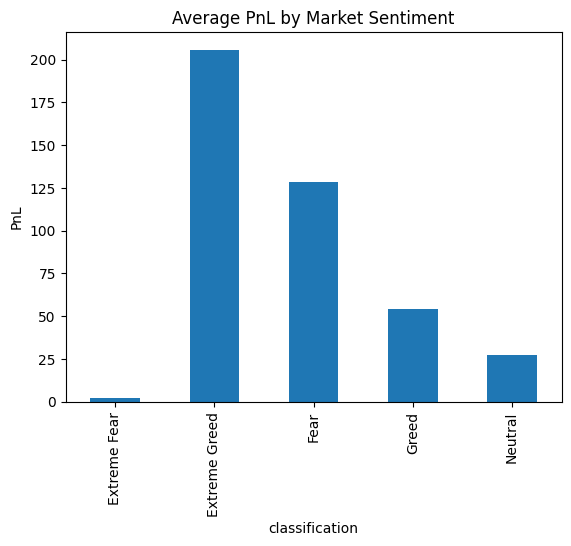

In [ ]:
df.groupby('classification')['Closed PnL'].mean().plot(kind='bar')

plt.title("Average PnL by Market Sentiment")
plt.ylabel("PnL")
plt.show()

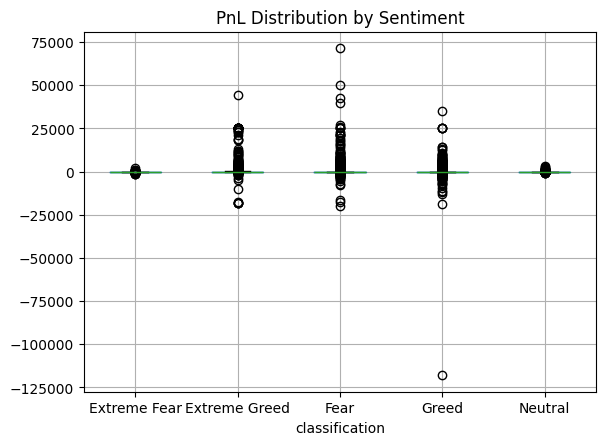

In [ ]:
df.boxplot(column='Closed PnL', by='classification')

plt.title("PnL Distribution by Sentiment")
plt.suptitle("")
plt.show()

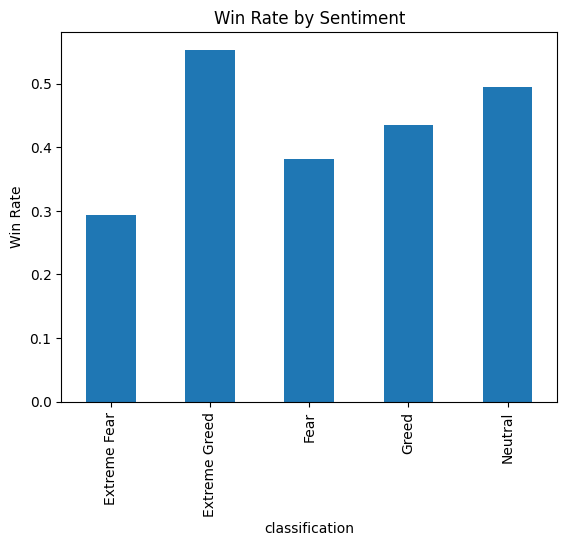

In [ ]:
df.groupby('classification')['win'].mean().plot(kind='bar')

plt.title("Win Rate by Sentiment")
plt.ylabel("Win Rate")
plt.show()